In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
from keras.layers import Dense, BatchNormalization, Dropout, LSTM
from keras.models import Sequential
from keras.utils import to_categorical
from keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, accuracy_score, f1_score
from keras import callbacks
import numpy as np
np.random.seed(0)

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "weatherAUS.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jsphyg/weather-dataset-rattle-package",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df.head()

/tmp/ipykernel_6299/3044558002.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 3.83M/3.83M [00:00<00:00, 122MB/s]

Extracting zip of weatherAUS.csv...


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

/tmp/ipykernel_6299/3613011121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= df["RainTomorrow"], palette= cols)


<Axes: xlabel='RainTomorrow', ylabel='count'>

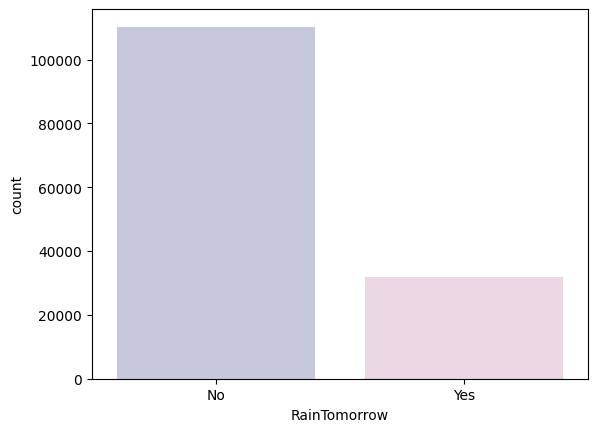

In [5]:
#first of all let us evaluate the target and find out if our data is imbalanced or not
cols= ["#C2C4E2","#EED4E5"]
sns.countplot(x= df["RainTomorrow"], palette= cols)

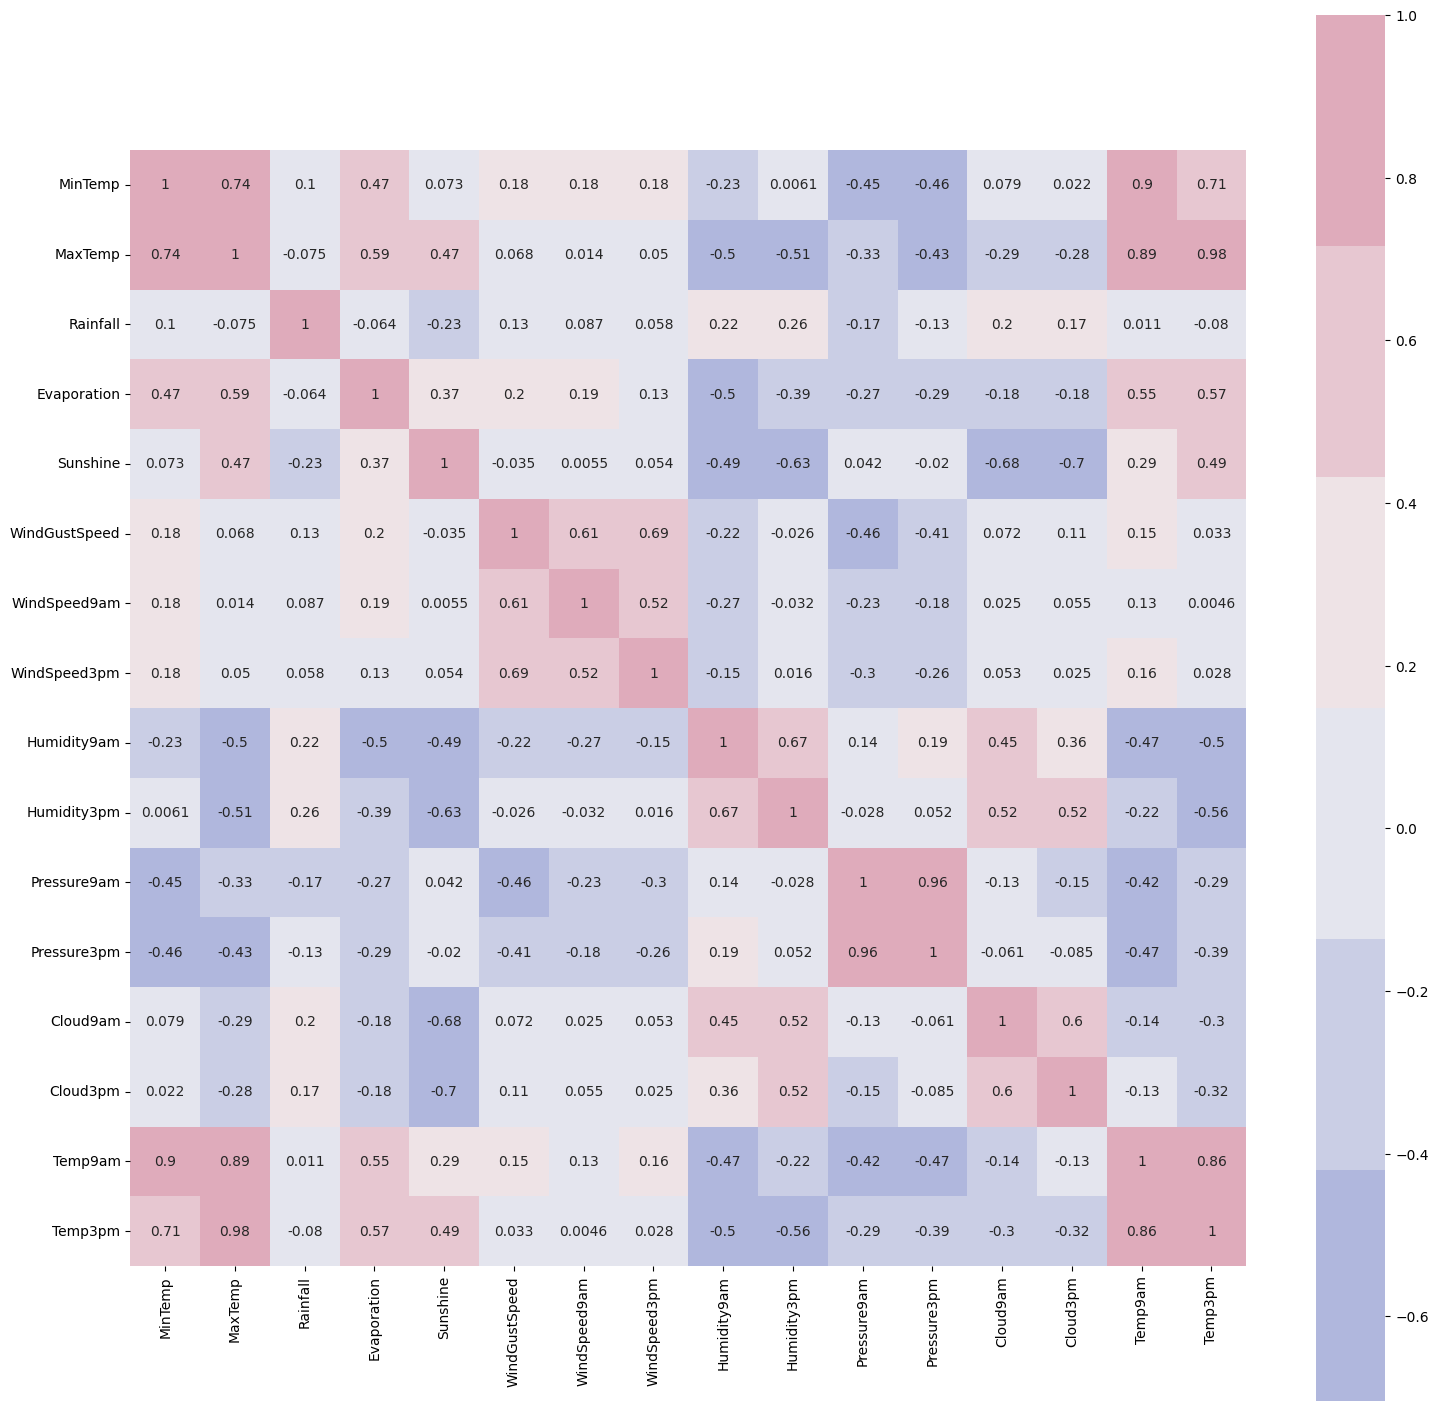

In [9]:
# Correlation amongst numeric attributes

# Keep only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Correlation matrix
corrmat = numeric_df.corr()

# Plot
cmap = sns.diverging_palette(260, -10, s=50, l=75, n=6, as_cmap=False)
plt.figure(figsize=(18,18))
sns.heatmap(corrmat, cmap=cmap, annot=True, square=True)

plt.show()

In [14]:
#Parsing datetime
#exploring the length of date objects
lengths=df['Date'].str.len()
lengths.value_counts()

,count
Date,
10,145460


In [15]:
df.shape

(145460, 23)

In [17]:
#There don't seem to be any error in dates so parsing values into datetime
import pandas as pd
df['Date']=pd.to_datetime(df['Date'])

# creating a column of year
df['year']=df.Date.dt.year

In [22]:
# function to encode datetime into cyclic parameters.
#As I am planning to use this data in a neural network I prefer the months and days in a cyclic continuous feature.

def encode(data, col, max_val):
    data[col + '_sin'] = np.sin(2 * np.pi * data[col]/max_val)
    data[col + '_cos'] = np.cos(2 * np.pi * data[col]/max_val)
    return data

df['Month']=df.Date.dt.month
df=encode(df,'Month',12)

df['Day']=df.Date.dt.day
df=encode(df,'Day',31)
df.sample(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Temp3pm,RainToday,RainTomorrow,year,Month,Month_sin,Month_cos,Day,Day_sin,Day_cos
87342,2009-04-22,Cairns,20.2,30.2,0.0,5.8,11.0,SE,46.0,S,...,28.5,No,No,2009,4,0.866025,-5.000000e-01,22,-0.968077,-0.250653
121287,2010-04-11,Perth,14.0,29.4,0.0,4.8,9.9,ENE,35.0,ENE,...,27.9,No,No,2010,4,0.866025,-5.000000e-01,11,0.790776,-0.612106
64212,2009-01-22,MelbourneAirport,15.1,35.6,0.0,8.0,7.6,W,94.0,NNW,...,34.7,No,No,2009,1,0.500000,8.660254e-01,22,-0.968077,-0.250653
119863,2015-05-13,PerthAirport,12.6,23.7,0.0,4.8,9.4,E,56.0,ENE,...,23.3,No,No,2015,5,0.500000,-8.660254e-01,13,0.485302,-0.874347
101548,2014-09-25,MountGambier,11.0,15.7,0.0,2.4,3.4,W,35.0,SSW,...,14.2,No,No,2014,9,-1.000000,-1.836970e-16,25,-0.937752,0.347305
67057,2017-02-03,MelbourneAirport,12.7,28.4,0.0,7.0,12.4,W,39.0,WSW,...,27.0,No,No,2017,2,0.866025,5.000000e-01,3,0.571268,0.820763
139351,2009-02-26,Darwin,25.2,31.7,1.6,2.8,4.0,N,43.0,NNE,...,30.9,Yes,Yes,2009,2,0.866025,5.000000e-01,26,-0.848644,0.528964
114194,2016-04-26,Witchcliffe,12.0,17.4,8.0,NaN,NaN,WNW,50.0,SW,...,16.1,Yes,Yes,2016,4,0.866025,-5.000000e-01,26,-0.848644,0.528964
42614,2009-02-06,Wollongong,20.7,27.7,0.0,NaN,NaN,SE,31.0,NNE,...,26.2,No,No,2009,2,0.866025,5.000000e-01,6,0.937752,0.347305
54519,2015-11-21,MountGinini,4.8,18.2,0.0,NaN,NaN,NW,43.0,SSW,...,16.9,No,No,2015,11,-0.500000,8.660254e-01,21,-0.897805,-0.440394


In [23]:
# roughly a year's span section

section=df[:360]
section

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Temp3pm,RainToday,RainTomorrow,year,Month,Month_sin,Month_cos,Day,Day_sin,Day_cos
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,21.8,No,No,2008,12,-2.449294e-16,1.000000,1,0.201299,0.979530
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,24.3,No,No,2008,12,-2.449294e-16,1.000000,2,0.394356,0.918958
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,23.2,No,No,2008,12,-2.449294e-16,1.000000,3,0.571268,0.820763
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,26.5,No,No,2008,12,-2.449294e-16,1.000000,4,0.724793,0.688967
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,29.7,No,No,2008,12,-2.449294e-16,1.000000,5,0.848644,0.528964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2009-11-21,Albury,19.3,21.0,10.6,NaN,NaN,NE,37.0,NE,...,20.8,Yes,Yes,2009,11,-5.000000e-01,0.866025,21,-0.897805,-0.440394
356,2009-11-22,Albury,18.3,28.3,25.8,NaN,NaN,NNW,61.0,NaN,...,25.6,Yes,No,2009,11,-5.000000e-01,0.866025,22,-0.968077,-0.250653
357,2009-11-23,Albury,11.9,23.6,0.4,NaN,NaN,W,24.0,WSW,...,22.7,No,No,2009,11,-5.000000e-01,0.866025,23,-0.998717,-0.050649
358,2009-11-24,Albury,12.8,25.8,0.0,NaN,NaN,WNW,30.0,SSE,...,24.9,No,No,2009,11,-5.000000e-01,0.866025,24,-0.988468,0.151428


Text(0.5, 0, 'Days in year')

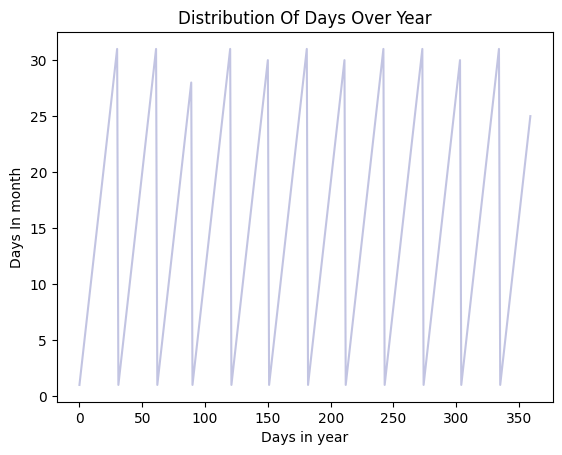

In [24]:
tm=section['Day'].plot(color="#C2C4E2")
tm.set_title('Distribution Of Days Over Year')
tm.set_ylabel('Days In month')
tm.set_xlabel('Days in year')

Text(0.5, 0, 'Sine Encoded Months')

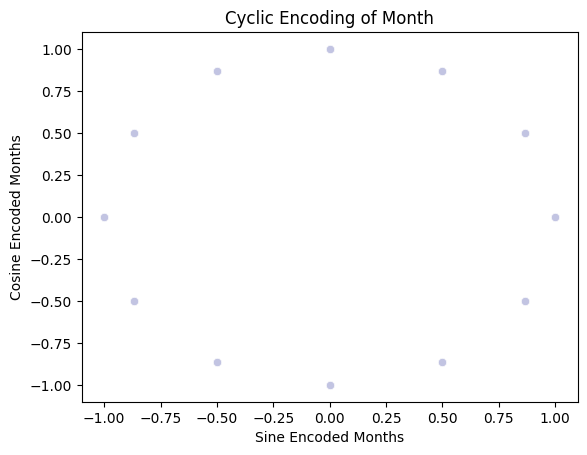

In [26]:
cyclic_month = sns.scatterplot(x="Month_sin",y="Month_cos",data=df, color="#C2C4E2")
cyclic_month.set_title("Cyclic Encoding of Month")
cyclic_month.set_ylabel("Cosine Encoded Months")
cyclic_month.set_xlabel("Sine Encoded Months")

Text(0.5, 0, 'Sine Encoded Day')

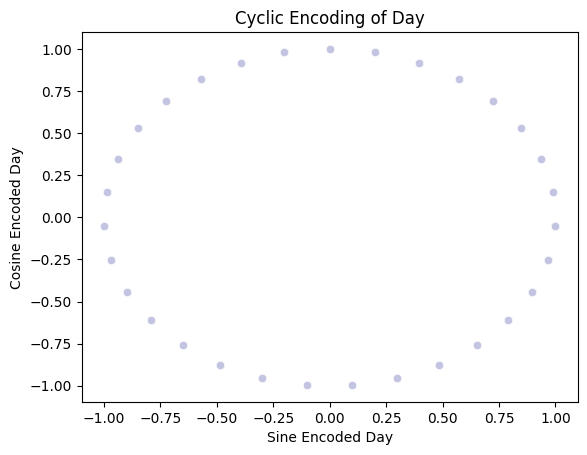

In [27]:
cyclic_day = sns.scatterplot(x='Day_sin',y='Day_cos',data=df, color="#C2C4E2")
cyclic_day.set_title("Cyclic Encoding of Day")
cyclic_day.set_ylabel("Cosine Encoded Day")
cyclic_day.set_xlabel("Sine Encoded Day")

In [30]:
# Get list of categorical variables
s=(df.dtypes=='object')
object_cols=list(s[s].index)
print('Categorical variable:')
print(object_cols)

Categorical variable:
['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [33]:
# Missing values in categorical variables
for i in object_cols:
  print(i , ' ', df[i].isnull().sum())

Location   0
WindGustDir   10326
WindDir9am   10566
WindDir3pm   4228
RainToday   3261
RainTomorrow   3267


In [34]:
# Filling missing values with mode of the column in value
for i in object_cols:
  df[i].fillna(df[i].mode()[0],inplace=True)

/tmp/ipykernel_6299/3433651994.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mode()[0],inplace=True)


In [35]:
for i in object_cols:
  print(i , ' ', df[i].isnull().sum())

Location   0
WindGustDir   0
WindDir9am   0
WindDir3pm   0
RainToday   0
RainTomorrow   0


In [39]:
# Get list of neumeric variables
t=(df.dtypes=='float64')
num_cols=list(t[t].index)
print('Numeric variables:')
print(num_cols)

Numeric variables:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos']


In [40]:
# missing values in numeric variables
for i in num_cols:
  print(i,df[i].isnull().sum())

MinTemp 1485
MaxTemp 1261
Rainfall 3261
Evaporation 62790
Sunshine 69835
WindGustSpeed 10263
WindSpeed9am 1767
WindSpeed3pm 3062
Humidity9am 2654
Humidity3pm 4507
Pressure9am 15065
Pressure3pm 15028
Cloud9am 55888
Cloud3pm 59358
Temp9am 1767
Temp3pm 3609
Month_sin 0
Month_cos 0
Day_sin 0
Day_cos 0


In [41]:
# filling missing value with median of the column in value
for i in num_cols:
  df[i].fillna(df[i].median(),inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 30 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  object        
 2   MinTemp        145460 non-null  float64       
 3   MaxTemp        145460 non-null  float64       
 4   Rainfall       145460 non-null  float64       
 5   Evaporation    145460 non-null  float64       
 6   Sunshine       145460 non-null  float64       
 7   WindGustDir    145460 non-null  object        
 8   WindGustSpeed  145460 non-null  float64       
 9   WindDir9am     145460 non-null  object        
 10  WindDir3pm     145460 non-null  object        
 11  WindSpeed9am   145460 non-null  float64       
 12  WindSpeed3pm   145460 non-null  float64       
 13  Humidity9am    145460 non-null  float64       
 14  Humidity3pm    145460 non-null  float64       
 15  

/tmp/ipykernel_6299/2087445228.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].median(),inplace=True)


In [42]:
for i in num_cols:
  print(i,df[i].isnull().sum())

MinTemp 0
MaxTemp 0
Rainfall 0
Evaporation 0
Sunshine 0
WindGustSpeed 0
WindSpeed9am 0
WindSpeed3pm 0
Humidity9am 0
Humidity3pm 0
Pressure9am 0
Pressure3pm 0
Cloud9am 0
Cloud3pm 0
Temp9am 0
Temp3pm 0
Month_sin 0
Month_cos 0
Day_sin 0
Day_cos 0


In [46]:
# Apply label encoder to each column with categorical data
label_encoder = LabelEncoder()
for i in object_cols:
    df[i] = label_encoder.fit_transform(df[i])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 30 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  int64         
 2   MinTemp        145460 non-null  float64       
 3   MaxTemp        145460 non-null  float64       
 4   Rainfall       145460 non-null  float64       
 5   Evaporation    145460 non-null  float64       
 6   Sunshine       145460 non-null  float64       
 7   WindGustDir    145460 non-null  int64         
 8   WindGustSpeed  145460 non-null  float64       
 9   WindDir9am     145460 non-null  int64         
 10  WindDir3pm     145460 non-null  int64         
 11  WindSpeed9am   145460 non-null  float64       
 12  WindSpeed3pm   145460 non-null  float64       
 13  Humidity9am    145460 non-null  float64       
 14  Humidity3pm    145460 non-null  float64       
 15  

In [48]:
# Prepairing attributes of scale data

features = df.drop(['RainTomorrow', 'Date','Day', 'Month'], axis=1) # dropping target and extra columns

target = df['RainTomorrow']

#Set up a standard scaler for the features
col_names = list(features.columns)
s_scaler = preprocessing.StandardScaler()
features = s_scaler.fit_transform(features)
features = pd.DataFrame(features, columns=col_names)

features.describe().T

,count,mean,std,min,25%,50%,75%,max
Location,145460.0,7.815677e-18,1.000003,-1.672228,-0.899139,0.014511,0.857881,1.701250
MinTemp,145460.0,-4.501830e-16,1.000003,-3.250525,-0.705659,-0.030170,0.723865,3.410112
MaxTemp,145460.0,3.001220e-16,1.000003,-3.952405,-0.735852,-0.086898,0.703133,3.510563
Rainfall,145460.0,7.815677e-18,1.000003,-0.275097,-0.275097,-0.275097,-0.203581,43.945571
Evaporation,145460.0,-3.282584e-17,1.000003,-1.629472,-0.371139,-0.119472,0.006361,43.985108
Sunshine,145460.0,-5.424080e-16,1.000003,-2.897217,0.076188,0.148710,0.257494,2.360634
WindGustDir,145460.0,6.252542e-18,1.000003,-1.724209,-0.872075,0.193094,1.045228,1.471296
WindGustSpeed,145460.0,1.824961e-16,1.000003,-2.588407,-0.683048,-0.073333,0.460168,7.243246
WindDir9am,145460.0,7.190423e-17,1.000003,-1.550000,-0.885669,0.000105,0.885879,1.771653
WindDir3pm,145460.0,8.284618e-17,1.000003,-1.718521,-0.837098,0.044324,0.925747,1.586813


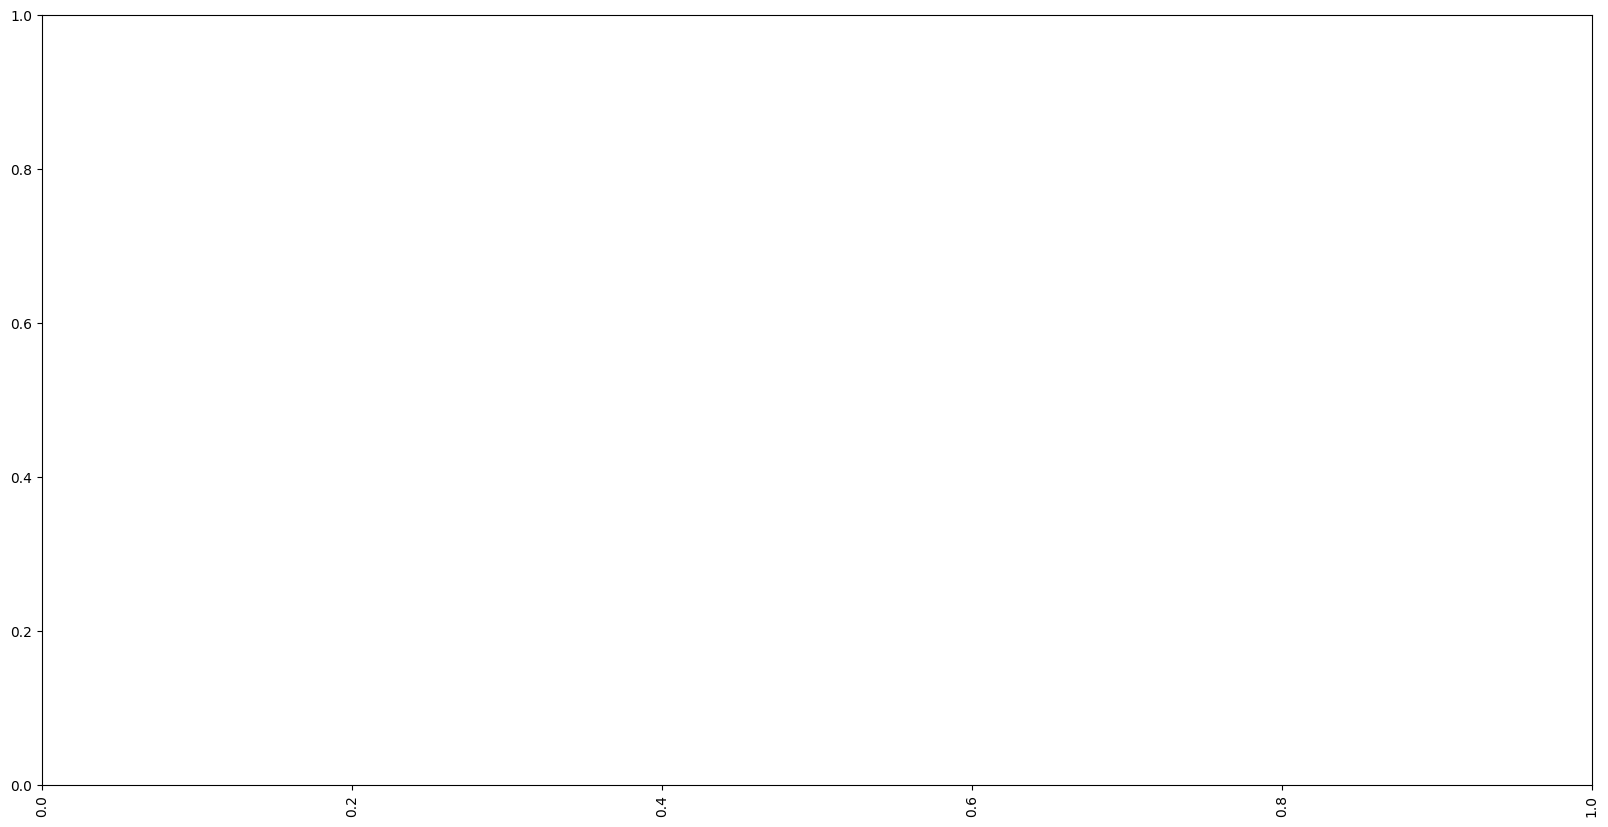

In [50]:
#Detecting outliers
#looking at the scaled features
import matplotlib.pyplot as plt
colours = ["#D0DBEE", "#C2C4E2", "#EED4E5", "#D1E6DC", "#BDE2E2"]
plt.figure(figsize=(20,10))
sns.boxenplot(df = features,palette = colours)
plt.xticks(rotation=90)
plt.show()

In [51]:
features

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,year,Month_sin,Month_cos,Day_sin,Day_cos
0,-1.531666,0.189757,-0.044575,-0.203581,-0.119472,0.14871,1.045228,0.307739,1.328766,1.366458,...,1.464068,0.137693,-0.013506,0.019135,-0.529795,-1.879575,-0.016425,1.434192,0.278970,1.426023
1,-1.531666,-0.752786,0.265794,-0.275097,-0.119472,0.14871,1.258262,0.307739,-0.221338,1.586813,...,0.149133,0.137693,0.033011,0.384064,-0.529795,-1.879575,-0.016425,1.434192,0.549587,1.339551
2,-1.531666,0.111212,0.350440,-0.275097,-0.119472,0.14871,1.471296,0.460168,1.328766,1.586813,...,0.149133,-1.286294,0.622225,0.223495,-0.529795,-1.879575,-0.016425,1.434192,0.797572,1.199371
3,-1.531666,-0.470023,0.674917,-0.275097,-0.119472,0.14871,-0.872075,-1.216548,0.442992,-1.718521,...,0.149133,0.137693,0.172562,0.705202,-0.529795,-1.879575,-0.016425,1.434192,1.012774,1.011221
4,-1.531666,0.833828,1.281548,-0.155903,-0.119472,0.14871,1.045228,0.079096,-1.328556,-0.176032,...,1.025756,1.561680,0.126045,1.172312,-0.529795,-1.879575,-0.016425,1.434192,1.186382,0.782805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,1.209285,-1.475402,0.025964,-0.275097,-0.119472,0.14871,-1.724209,-0.683048,0.442992,-1.498165,...,0.149133,0.137693,-1.067887,0.106718,-0.529795,1.666978,-0.016425,-1.388032,-1.261688,-0.601030
145456,1.209285,-1.349730,0.294010,-0.275097,-0.119472,0.14871,-0.446007,-1.368977,0.442992,-1.057454,...,0.149133,0.137693,-0.943842,0.413259,-0.529795,1.666978,-0.016425,-1.388032,-1.360192,-0.330159
145457,1.209285,-1.066967,0.519733,-0.275097,-0.119472,0.14871,-1.085108,-0.225761,0.442992,1.366458,...,0.149133,0.137693,-0.695753,0.646814,-0.529795,1.666978,-0.016425,-1.388032,-1.403140,-0.044639
145458,1.209285,-0.689950,0.533840,-0.275097,-0.119472,0.14871,0.193094,-0.911691,0.664436,-1.057454,...,-0.727490,-1.286294,-0.292607,0.632217,-0.529795,1.666978,-0.016425,-1.388032,-1.388775,0.243842


In [52]:
#full data for
features["RainTomorrow"] = target

#Dropping with outlier

features = features[(features["MinTemp"]<2.3)&(features["MinTemp"]>-2.3)]
features = features[(features["MaxTemp"]<2.3)&(features["MaxTemp"]>-2)]
features = features[(features["Rainfall"]<4.5)]
features = features[(features["Evaporation"]<2.8)]
features = features[(features["Sunshine"]<2.1)]
features = features[(features["WindGustSpeed"]<4)&(features["WindGustSpeed"]>-4)]
features = features[(features["WindSpeed9am"]<4)]
features = features[(features["WindSpeed3pm"]<2.5)]
features = features[(features["Humidity9am"]>-3)]
features = features[(features["Humidity3pm"]>-2.2)]
features = features[(features["Pressure9am"]< 2)&(features["Pressure9am"]>-2.7)]
features = features[(features["Pressure3pm"]< 2)&(features["Pressure3pm"]>-2.7)]
features = features[(features["Cloud9am"]<1.8)]
features = features[(features["Cloud3pm"]<2)]
features = features[(features["Temp9am"]<2.3)&(features["Temp9am"]>-2)]
features = features[(features["Temp3pm"]<2.3)&(features["Temp3pm"]>-2)]


features.shape

(127536, 27)

/tmp/ipykernel_6299/1688296607.py:4: UserWarning: 
The palette list has fewer values (5) than needed (27) and will cycle, which may produce an uninterpretable plot.
  sns.boxenplot(data = features,palette = colours)


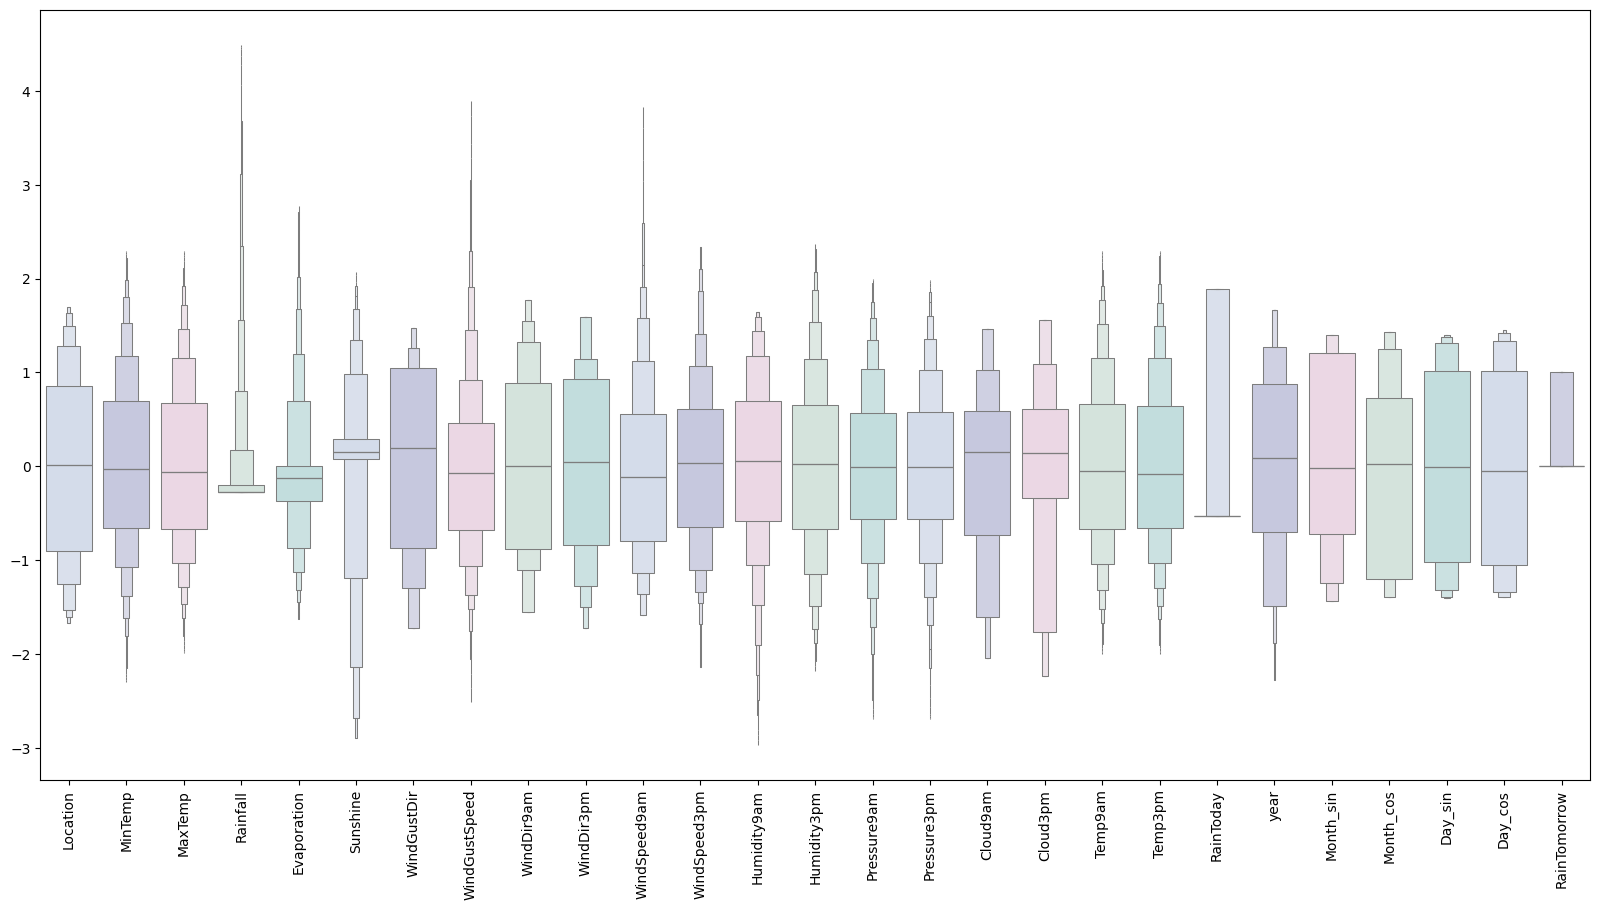

In [53]:
#looking at the scaled features without outliers

plt.figure(figsize=(20,10))
sns.boxenplot(data = features,palette = colours)
plt.xticks(rotation=90)
plt.show()

In [54]:
X = features.drop(["RainTomorrow"], axis=1)
y = features["RainTomorrow"]

# Splitting test and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X.shape

(127536, 26)

In [55]:
# Early_stoping
early_stopping=callbacks.EarlyStopping(
    min_delta=0.0001,
    patience=20,
    restore_best_weights=True
)

# Initialising the NN
model=Sequential()

# layers
model.add(Dense(units=32,kernel_initializer='uniform',activation='relu',input_dim=26))
model.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dense(units = 16, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dropout(0.25))
model.add(Dense(units = 8, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))

# compiling the ANN
opt=Adam(learning_rate=0.00009)
model.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])

# Train the ANN
history=model.fit(X_train,y_train,batch_size=32,epochs=150,callbacks=[early_stopping],validation_split=0.2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
2551/2551 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7841 - loss: 0.4712 - val_accuracy: 0.7860 - val_loss: 0.3933
Epoch 2/150
2551/2551 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7991 - loss: 0.4118 - val_accuracy: 0.8341 - val_loss: 0.3854
Epoch 3/150
2551/2551 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8112 - loss: 0.4052 - val_accuracy: 0.8381 - val_loss: 0.3799
Epoch 4/150
2551/2551 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8121 - loss: 0.4007 - val_accuracy: 0.8398 - val_loss: 0.3762
Epoch 5/150
2551/2551 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8123 - loss: 0.3977 - val_accuracy: 0.8406 - val_loss: 0.3734
Epoch 6/150
2551/2551 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8147 - loss: 0.3957 - val_accuracy: 0.8408 - val_loss: 0.3712
Epoch 7/150
2551/2551 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8151 - loss: 0.3948 - val_accuracy: 0.8423 - val_loss: 0.3693
Epoch 8/150
2551/2551 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8146 - loss:

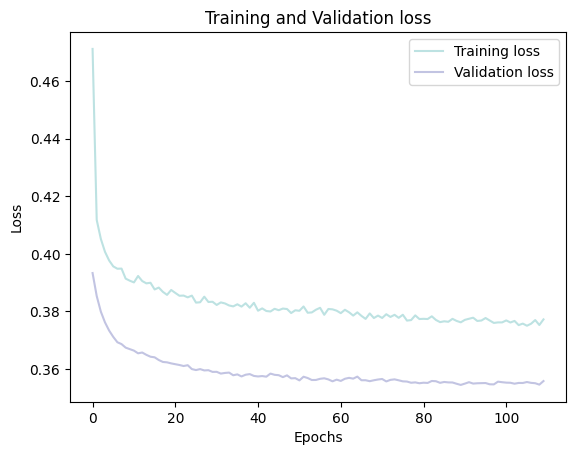

In [56]:
history_df = pd.DataFrame(history.history)

plt.plot(history_df.loc[:, ['loss']], "#BDE2E2", label='Training loss')
plt.plot(history_df.loc[:, ['val_loss']],"#C2C4E2", label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="best")

plt.show()

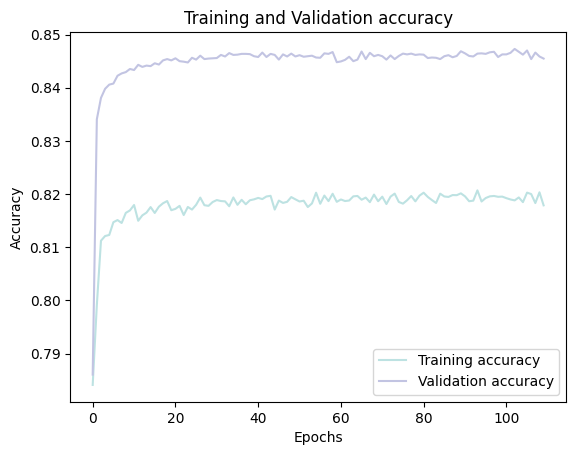

In [57]:
history_df = pd.DataFrame(history.history)

plt.plot(history_df.loc[:, ['accuracy']], "#BDE2E2", label='Training accuracy')
plt.plot(history_df.loc[:, ['val_accuracy']], "#C2C4E2", label='Validation accuracy')

plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [58]:
# Predicting the test set results
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

798/798 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


<Axes: >

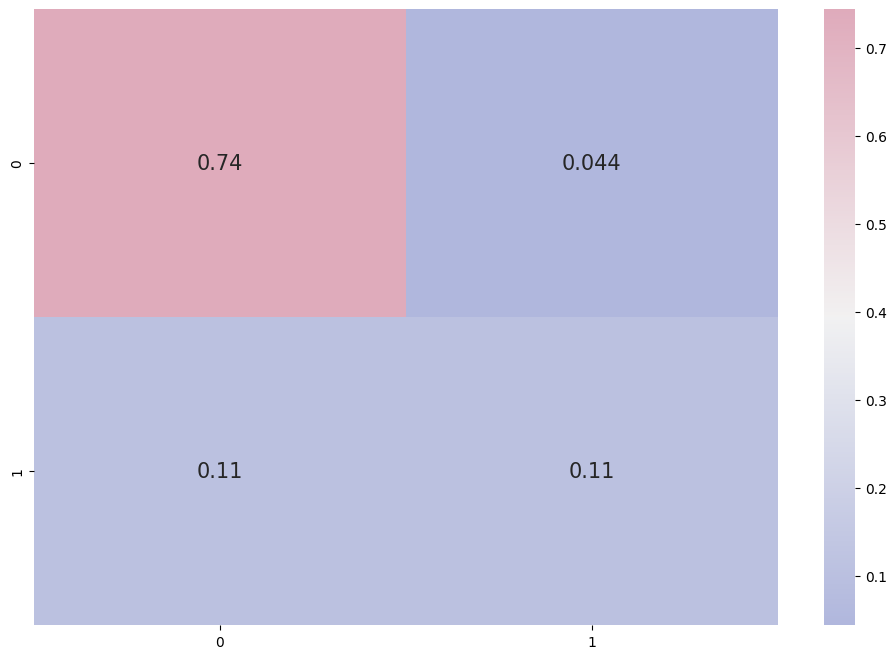

In [59]:
# confusion matrix
cmap1 = sns.diverging_palette(260,-10,s=50, l=75, n=5, as_cmap=True)
plt.subplots(figsize=(12,8))
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix/np.sum(cf_matrix), cmap = cmap1, annot = True, annot_kws = {'size':15})

In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91     20110
           1       0.70      0.50      0.58      5398

    accuracy                           0.85     25508
   macro avg       0.79      0.72      0.75     25508
weighted avg       0.84      0.85      0.84     25508

